In [1]:
# Process and plot lacto supernatant inhibition on enterobacteria

In [2]:
getwd()
#setwd("/home/strawperry/Documentos/lactos-joao/lacto-supernatant-inhibition/")
#getwd()

[1] "/home/strawberry/Documents/Masters/lactos"

In [8]:
#install.packages("pracma")

In [10]:
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)
library(pracma)  # for trapz()

In [11]:
getwd()

[1] "/home/strawberry/Documents/Masters/lactos"

In [ ]:
# list the three time-point files
library(readr)
library(stringr)
library(purrr)

files <- sort(list.files(
  path = ".",
  pattern = "^040626_\\d+h\\.tsv$",
  recursive = FALSE,
  full.names = TRUE
))
files

[1] "./040626_0h.tsv"  "./040626_24h.tsv" "./040626_6h.tsv"

In [21]:
# Read the three plate files and combine them into one tidy table
read_plate_tsv <- function(file_path) {
  raw <- read_tsv(file_path, show_col_types = FALSE)

  # First column contains the row labels (A-H)
  names(raw)[1] <- "row"

  raw %>%
    mutate(row = as.character(row)) %>%
    pivot_longer(
      cols = -row,
      names_to = "column",
      values_to = "OD600"
    ) %>%
    mutate(
      column = as.integer(column),
      well = sprintf("%s%02d", row, column),
      date = str_extract(basename(file_path), "\\d{6}"),
      time = str_extract(basename(file_path), "\\d+h"),
      time_h = as.numeric(str_remove(time, "h")),
      time_s = time_h * 3600,
      source = basename(file_path)
    ) %>%
    select(date, time, time_h, time_s, source, well, row, column, OD600)
}

plates_df <- map_dfr(files, read_plate_tsv)
long_df <- plates_df

head(plates_df)

date,time,time_h,time_s,source,well,row,column,OD600
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>
040626,0h,0,0,040626_0h.tsv,A01,A,1,0.0677
040626,0h,0,0,040626_0h.tsv,A02,A,2,0.0680
040626,0h,0,0,040626_0h.tsv,A03,A,3,0.0685
040626,0h,0,0,040626_0h.tsv,A04,A,4,0.0688
040626,0h,0,0,040626_0h.tsv,A05,A,5,0.0692
040626,0h,0,0,040626_0h.tsv,A06,A,6,0.0689


In [22]:
tail(long_df)

date,time,time_h,time_s,source,well,row,column,OD600
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>
040626,6h,6,21600,040626_6h.tsv,H07,H,7,0.2896
040626,6h,6,21600,040626_6h.tsv,H08,H,8,0.2629
040626,6h,6,21600,040626_6h.tsv,H09,H,9,0.2647
040626,6h,6,21600,040626_6h.tsv,H10,H,10,0.2829
040626,6h,6,21600,040626_6h.tsv,H11,H,11,0.2734
040626,6h,6,21600,040626_6h.tsv,H12,H,12,0.2624


In [23]:
# Add plate conditions
# - MilliQ water on borders: rows A and H, columns 1 and 12
# - Lacto 14: rows B, C, D
# - Lacto 30: rows E, F, G
# - C.perfringens 49-24: columns 2, 3, 4, 5, 6
# - C.perfringens 52-27: columns 7, 8, 9, 10, 11
# - Neg control: wells D06, E06, D11, E11  (renamed to C_neg)
# - Pos control: wells B06, C06 (lacto 14 x C.perfringens 49-24), F06, G06 (lacto 30 x C.perfringens 49-24), B11, C11 (lacto 14 x C.perfringens 52-27), F11, G11 (lacto 30 x C.perfringens 52-27)  (renamed to C_pos)

plates_long2 <- long_df %>%
  mutate(
    condition = case_when(
      (row == "D" & column == 6L) |
      (row == "E" & column == 6L) |
      (row == "D" & column == 11L) |
      (row == "E" & column == 11L) ~ "C_neg",
      row %in% c("A", "H") | column %in% c(1L, 12L) ~ "MilliQ water",
      row %in% c("B", "C", "D") & column %in% 2:6 ~ "Lacto 14 x C.perfringens 49-24",
      row %in% c("B", "C", "D") & column %in% 7:11 ~ "Lacto 14 x C.perfringens 52-27",
      row %in% c("E", "F", "G") & column %in% 2:6 ~ "Lacto 30 x C.perfringens 49-24",
      row %in% c("E", "F", "G") & column %in% 7:11 ~ "Lacto 30 x C.perfringens 52-27",
      TRUE ~ "Unassigned"
    ),
    plate_row = case_when(
      row %in% c("A", "H") ~ "Border",
      row %in% c("B", "C", "D") ~ "Lacto 14",
      row %in% c("E", "F", "G") ~ "Lacto 30",
      TRUE ~ NA_character_
    ),
    plate_col = case_when(
      column %in% c(1L, 12L) ~ "Border",
      column %in% 2:6 ~ "C.perfringens 49-24",
      column %in% 7:11 ~ "C.perfringens 52-27",
      TRUE ~ NA_character_
    ),
    Lacto_ID = case_when(
      condition %in% c("MilliQ water", "C_neg") ~ NA_character_,
      row %in% c("B", "C", "D") ~ "14",
      row %in% c("E", "F", "G") ~ "30",
      TRUE ~ NA_character_
    ),
    Entero_ID = case_when(
      condition %in% c("MilliQ water", "C_neg") ~ NA_character_,
      column %in% 2:6 ~ "49-24",
      column %in% 7:11 ~ "52-27",
      TRUE ~ NA_character_
    ),
    Strain = case_when(
      !is.na(Entero_ID) & !is.na(Lacto_ID) ~ paste0("L", Lacto_ID, "_E", Entero_ID),
      condition %in% c("MilliQ water", "C_neg") ~ condition,
      TRUE ~ NA_character_
    ),
    well = sprintf("%s%02d", row, column)
  ) %>%
  select(Entero_ID, Lacto_ID, Strain, plate_row, plate_col, condition, time_s, time_h, well, row, column, OD600)

head(plates_long2)

Entero_ID,Lacto_ID,Strain,plate_row,plate_col,condition,time_s,time_h,well,row,column,OD600
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
NA,NA,MilliQ water,Border,Border,MilliQ water,0,0,A01,A,1,0.0677
NA,NA,MilliQ water,Border,C.perfringens 49-24,MilliQ water,0,0,A02,A,2,0.0680
NA,NA,MilliQ water,Border,C.perfringens 49-24,MilliQ water,0,0,A03,A,3,0.0685
NA,NA,MilliQ water,Border,C.perfringens 49-24,MilliQ water,0,0,A04,A,4,0.0688
NA,NA,MilliQ water,Border,C.perfringens 49-24,MilliQ water,0,0,A05,A,5,0.0692
NA,NA,MilliQ water,Border,C.perfringens 49-24,MilliQ water,0,0,A06,A,6,0.0689


In [24]:
# Mark the pair-specific positive controls so they do not get mixed into the 1/16 dilution wells
plates_long2 <- plates_long2 %>%
  mutate(
    is_pos_control = well %in% c("B06", "C06", "F06", "G06", "B11", "C11", "F11", "G11"),
    condition = case_when(
      is_pos_control ~ "C_pos",
      TRUE ~ condition
    )
  )

plates_long2 %>%
  filter(is_pos_control) %>%
  distinct(Entero_ID, Lacto_ID, well, condition)

Entero_ID,Lacto_ID,well,condition
<chr>,<chr>,<chr>,<chr>
49-24,14,B06,C_pos
52-27,14,B11,C_pos
49-24,14,C06,C_pos
52-27,14,C11,C_pos
49-24,30,F06,C_pos
52-27,30,F11,C_pos
49-24,30,G06,C_pos
52-27,30,G11,C_pos


In [25]:
# Make a summarized table to plot from plates_long2
plates_long3 <- plates_long2 %>%
  select(Entero_ID, Lacto_ID, well, condition, time_h, OD600) %>%
  mutate(
    column = as.integer(substr(well, 2, 3)),
    dilution = case_when(
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      column %in% c(2L, 7L) ~ "1/2",
      column %in% c(3L, 8L) ~ "1/4",
      column %in% c(4L, 9L) ~ "1/8",
      column %in% c(5L, 10L) ~ "1/16",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(
    !is.na(Entero_ID),
    !is.na(Lacto_ID),
    !is.na(well),
    !is.na(condition),
    !is.na(time_h),
    !is.na(OD600),
    !is.na(dilution)
  ) %>%
  arrange(Entero_ID, Lacto_ID, well, condition, time_h)

head(plates_long3)

Entero_ID,Lacto_ID,well,condition,time_h,OD600,column,dilution
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
49-24,14,B02,Lacto 14 x C.perfringens 49-24,0,0.1456,2,1/2
49-24,14,B02,Lacto 14 x C.perfringens 49-24,6,0.4026,2,1/2
49-24,14,B02,Lacto 14 x C.perfringens 49-24,24,0.3453,2,1/2
49-24,14,B03,Lacto 14 x C.perfringens 49-24,0,0.1202,3,1/4
49-24,14,B03,Lacto 14 x C.perfringens 49-24,6,0.3486,3,1/4
49-24,14,B03,Lacto 14 x C.perfringens 49-24,24,0.4408,3,1/4


In [26]:
# COLOR PALETTE FOR DILUTIONS AND CONTROLS
# Define a named color map for reuse in all plots
color_map <- c(
  "1" = "#1B9E77",
  "1/2" = "#1B9E77",
  "1/4" = "#D95F02",
  "1/8" = "#7570B3",
  "1/16" = "#E7298A",
  "C_pos" = "#000000",
  "C_neg" = "#7a7a7a"
)


`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 6.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 328.33”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“span too small.   fewer data values than degrees of freedom.”
Warning message in predLoess(object$y, object$x, newx = if (is.nu

Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“span too small.   fewer data values than degrees of freedom.”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“pseudoinverse used at -0.12”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“neighborhood radius 6.12”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“reciprocal condition number  0”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(d

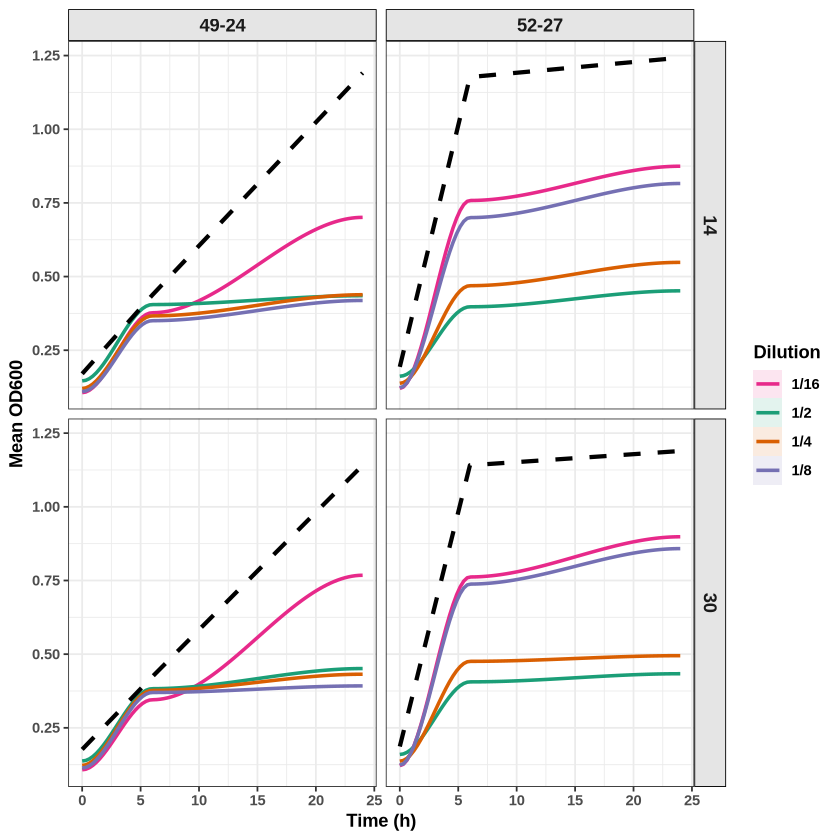

In [42]:
# Ensure proper control labeling
plates_long4 <- plates_long3 %>%
  mutate(
    control_type = case_when(
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      TRUE ~ NA_character_
    ),

    dilution_group = case_when(
      condition %in% c("C_neg") ~ NA_character_,
      condition == "C_pos" ~ NA_character_,
      TRUE ~ dilution
    )
  )

# Summary for everything
summary_df <- plates_long4 %>%
  group_by(Entero_ID, Lacto_ID, dilution_group, control_type, time_h) %>%
  summarise(
    mean_OD600 = mean(OD600, na.rm = TRUE),
    sd_OD600 = sd(OD600, na.rm = TRUE),
    n = dplyr::n(),
    se_OD600 = sd_OD600 / sqrt(n),
    .groups = "drop"
  )

# Clean plot with BLACK control lines per facet
ggplot(summary_df, aes(x = time_h, y = mean_OD600)) +

  # =========================
  # 1. Dilutions (colored + smooth)
  # =========================
  geom_smooth(
    data = subset(summary_df, !is.na(dilution_group)),
    aes(color = dilution_group, fill = dilution_group, group = dilution_group),
    method = "loess",
    se = TRUE,
    linewidth = 1,
    alpha = 0.12
  ) +

  # =========================
  # 2. Negative + Positive controls (BLACK lines, DASHED)
  # =========================
  geom_line(
    data = subset(summary_df, !is.na(control_type)),
    aes(group = control_type),
    color = "black",
    linewidth = 1.2,
    linetype = "dashed"
  ) +

  facet_grid(Lacto_ID ~ Entero_ID) +

  scale_color_manual(values = color_map[c("1", "1/2", "1/4", "1/8", "1/16")]) +
  scale_fill_manual(values = color_map[c("1", "1/2", "1/4", "1/8", "1/16")]) +

  labs(
    x = "Time (h)",
    y = "Mean OD600",
    color = "Dilution",
    fill = "Dilution"
  ) +

  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey90", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(face = "bold")
  )

In [43]:
# Helper: estimate growth rate (doublings per hour) from time_h and OD600 for one well
estimate_growth_rate <- function(df){
  if(!all(c("time_h","OD600") %in% names(df))) return(NA_real_)
  d <- df %>% dplyr::filter(!is.na(time_h) & !is.na(OD600))
  if(nrow(d) < 2) return(NA_real_)
  d <- d %>% dplyr::filter(OD600 > 0)
  if(nrow(d) < 2) return(NA_real_)
  # fit linear slope on log2(OD) vs time_h -> slope is doublings per hour
  res <- tryCatch({
    fit <- stats::lm(log2(OD600) ~ time_h, data = d)
    coef <- stats::coef(fit)["time_h"]
    as.numeric(coef)
  }, error = function(e) NA_real_)
  return(res)
}


Entero_ID,Lacto_ID,series,well,growth_rate
<chr>,<chr>,<chr>,<chr>,<dbl>
49-24,14,1/16,B05,0.09810581
49-24,14,1/16,C05,0.10069716
49-24,14,1/16,D05,0.09742024
49-24,14,1/2,B02,0.03709107
49-24,14,1/2,C02,0.06029374
49-24,14,1/2,D02,0.05575282


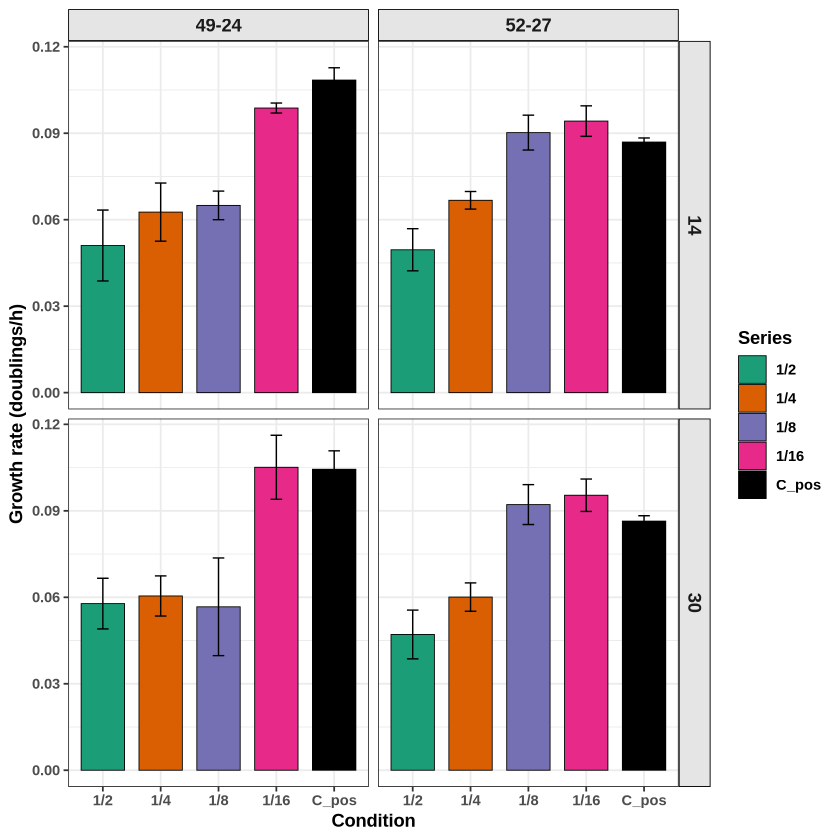

In [44]:
growth_rate_df <- plates_long4 %>%
  mutate(
    series = case_when(
      dilution %in% c("1/2","1/4","1/8","1/16") ~ dilution,
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      TRUE ~ NA_character_
    )
  ) %>%
  group_by(Entero_ID, Lacto_ID, series, well) %>%
  group_modify(~ tibble(
    growth_rate = estimate_growth_rate(.x)
  )) %>%
  ungroup()

head(growth_rate_df)


rate_summary <- growth_rate_df %>%
  group_by(Entero_ID, Lacto_ID, series) %>%
  summarise(
    mean_rate = mean(growth_rate, na.rm = TRUE),
    sd_rate = sd(growth_rate, na.rm = TRUE),
    n = sum(!is.na(growth_rate)),
    .groups = "drop"
  ) %>%
  ungroup()

# Remove C_neg entries (no meaningful growth rate) and order series so C_pos plots on the right
rate_summary <- rate_summary %>%
  filter(series != "C_neg")

all_series <- c("1/2", "1/4", "1/8", "1/16", "C_pos")

rate_summary <- rate_summary %>%
  tidyr::complete(Entero_ID, Lacto_ID, series = all_series, fill = list(mean_rate = NA_real_, sd_rate = NA_real_, n = 0)) %>%
  mutate(
    series = factor(series, levels = all_series),
    mean_rate_plot = ifelse(is.na(mean_rate), 0, mean_rate)
  )

ggplot(rate_summary, aes(x = series, y = mean_rate_plot)) +

  geom_col(aes(fill = series),
           color = "black",
           linewidth = 0.25,
           width = 0.75) +

  geom_errorbar(
    aes(ymin = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot - sd_rate),
        ymax = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot + sd_rate)),
    width = 0.2,
    linewidth = 0.4,
    na.rm = TRUE
  ) +

  facet_grid(Lacto_ID ~ Entero_ID) +

  scale_fill_manual(values = color_map[c("1/2", "1/4", "1/8", "1/16", "C_pos")]) +

  labs(
    x = "Condition",
    y = "Growth rate (doublings/h)",
    fill = "Series"
  ) + 

  theme_bw() +
  
  theme(
    strip.background = element_rect(fill = "grey90", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(face = "bold")
  )

Entero_ID,Lacto_ID,series,well,growth_rate,window_start,window_end,n_pts
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
49-24,14,1/16,B05,0.3019112,0,6,2
49-24,14,1/16,C05,0.3119940,0,6,2
49-24,14,1/16,D05,0.3009407,0,6,2
49-24,14,1/2,B02,0.2445561,0,6,2
49-24,14,1/2,C02,0.2423386,0,6,2
49-24,14,1/2,D02,0.2490798,0,6,2


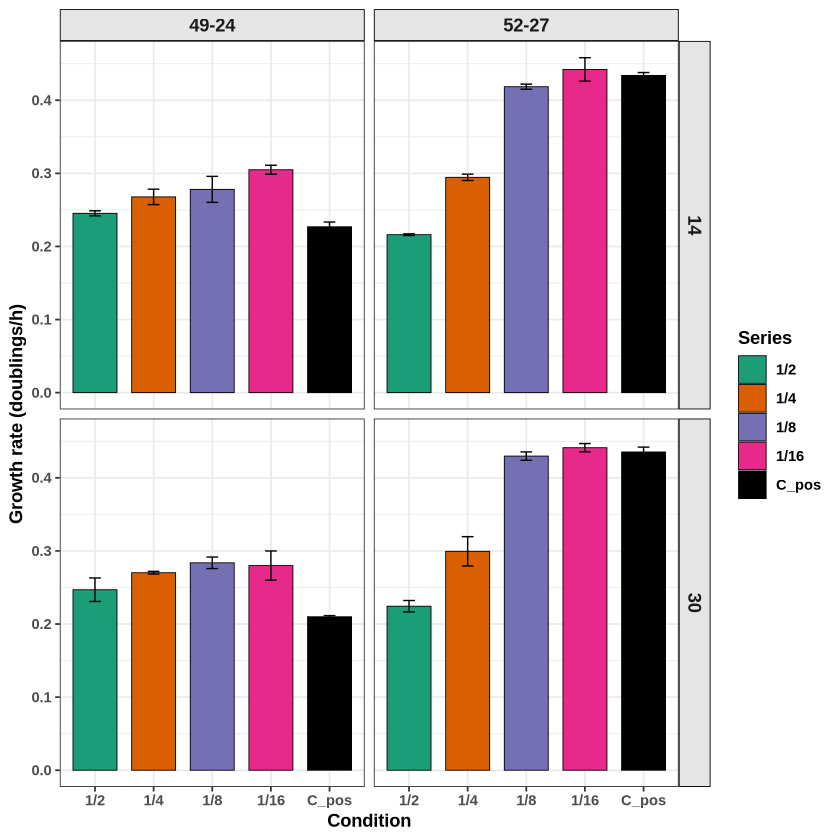

In [45]:
# --- Alternative: estimate growth rate using exponential-phase window selection ---
# For each well, consider all contiguous windows of length >=2 and select the window
# with the largest slope of log2(OD600) vs time_h (doublings per hour). Return the
# slope, window boundaries and number of points used.
estimate_growth_rate_exp <- function(df){
  if(!all(c("time_h","OD600") %in% names(df))) return(tibble(growth_rate = NA_real_, window_start = NA_real_, window_end = NA_real_, n_pts = 0))
  d <- df %>% dplyr::filter(!is.na(time_h) & !is.na(OD600) & OD600 > 0) %>% arrange(time_h)
  n <- nrow(d)
  if(n < 2) return(tibble(growth_rate = NA_real_, window_start = NA_real_, window_end = NA_real_, n_pts = n))

  best_slope <- -Inf
  best_i <- NA_integer_
  best_j <- NA_integer_

  for(i in seq_len(n-1)){
    for(j in seq(i+1, n)){
      sub <- d[i:j, , drop = FALSE]
      fit <- tryCatch(stats::lm(log2(OD600) ~ time_h, data = sub), error = function(e) NULL)
      if(!is.null(fit)){
        slope <- as.numeric(stats::coef(fit)["time_h"])
        if(!is.na(slope) && slope > best_slope){
          best_slope <- slope
          best_i <- i
          best_j <- j
        }
      }
    }
  }

  if(is.infinite(best_slope) || is.na(best_slope)){
    return(tibble(growth_rate = NA_real_, window_start = NA_real_, window_end = NA_real_, n_pts = n))
  }

  window_start <- d$time_h[best_i]
  window_end   <- d$time_h[best_j]
  n_pts_used   <- best_j - best_i + 1

  tibble(growth_rate = as.numeric(best_slope), window_start = window_start, window_end = window_end, n_pts = n_pts_used)
}

# Apply the exponential-phase estimator per well and summarize per series
growth_rate_exp_df <- plates_long4 %>%
  mutate(
    series = case_when(
      dilution %in% c("1/2","1/4","1/8","1/16") ~ dilution,
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      TRUE ~ NA_character_
    )
  ) %>%
  group_by(Entero_ID, Lacto_ID, series, well) %>%
  group_modify(~ estimate_growth_rate_exp(.x)) %>%
  ungroup()

head(growth_rate_exp_df)

# Summary (mean ± SD) per Entero x Lacto x series
rate_summary_exp <- growth_rate_exp_df %>%
  group_by(Entero_ID, Lacto_ID, series) %>%
  summarise(
    mean_rate = mean(growth_rate, na.rm = TRUE),
    sd_rate = sd(growth_rate, na.rm = TRUE),
    n = sum(!is.na(growth_rate)),
    .groups = "drop"
  ) %>%
  ungroup()

# Remove C_neg and complete factor ordering so comparisons are consistent
rate_summary_exp <- rate_summary_exp %>%
  filter(series != "C_neg") %>%
  tidyr::complete(Entero_ID, Lacto_ID, series = c("1/2","1/4","1/8","1/16","C_pos"), fill = list(mean_rate = NA_real_, sd_rate = NA_real_, n = 0)) %>%
  mutate(series = factor(series, levels = c("1/2","1/4","1/8","1/16","C_pos")), mean_rate_plot = ifelse(is.na(mean_rate), 0, mean_rate))

# Quick barplot of mean ± SD for the exponential-phase method
ggplot(rate_summary_exp, aes(x = series, y = mean_rate_plot)) +
  geom_col(aes(fill = series), color = "black", linewidth = 0.25, width = 0.75) +
  geom_errorbar(aes(ymin = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot - sd_rate), ymax = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot + sd_rate)), width = 0.2, linewidth = 0.4, na.rm = TRUE) +
  facet_grid(Lacto_ID ~ Entero_ID) +
  scale_fill_manual(values = color_map[c("1/2","1/4","1/8","1/16","C_pos")]) +
  labs(x = "Condition", y = "Growth rate (doublings/h)", fill = "Series") +
  theme_bw() + theme(strip.background = element_rect(fill = "grey90", color = "black"), strip.text = element_text(face = "bold", size = 11), axis.title = element_text(face = "bold"), axis.text = element_text(face = "bold"), legend.title = element_text(face = "bold"), legend.text = element_text(face = "bold"))


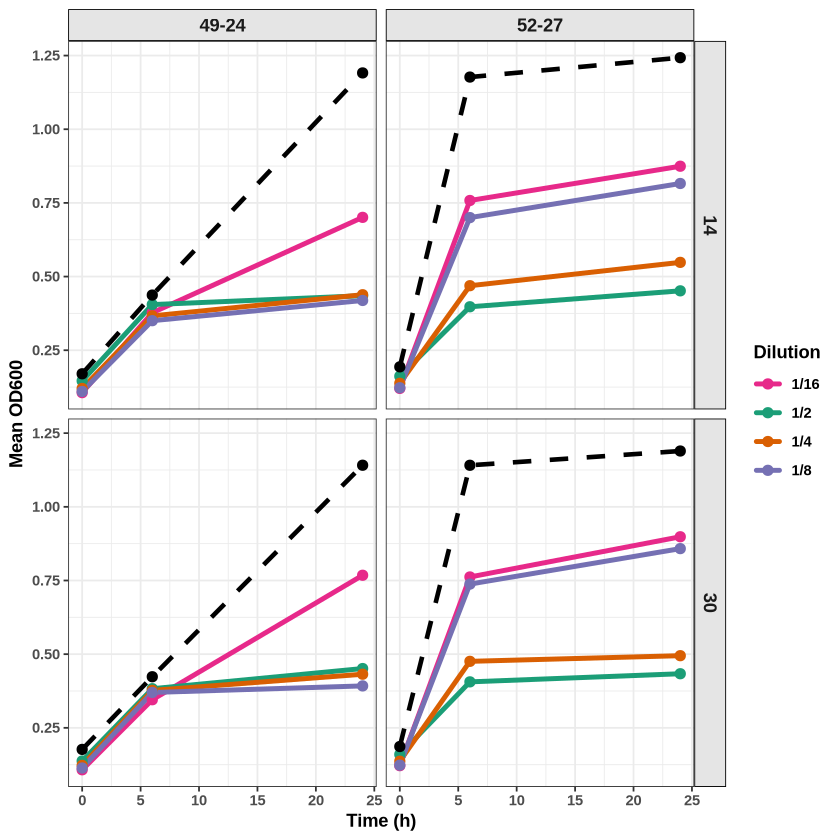

In [41]:
ggplot(summary_df, aes(x = time_h, y = mean_OD600)) +

  # =========================
  # 1. Dilutions (colored lines)
  # =========================
  geom_line(
    data = subset(summary_df, !is.na(dilution_group)),
    aes(
      color = dilution_group,
      group = dilution_group
    ),
    linewidth = 1.4,
    lineend = "round"
  ) +

  geom_point(
    data = subset(summary_df, !is.na(dilution_group)),
    aes(color = dilution_group),
    size = 2.5
  ) +

  # =========================
  # 2. Controls (black dashed)
  # =========================
  geom_line(
    data = subset(summary_df, !is.na(control_type)),
    aes(group = control_type),
    color = "black",
    linewidth = 1.3,
    linetype = "dashed"
  ) +

  geom_point(
    data = subset(summary_df, !is.na(control_type)),
    color = "black",
    size = 2.5
  ) +

  facet_grid(Lacto_ID ~ Entero_ID) +

  scale_color_manual(
    values = color_map[c("1", "1/2", "1/4", "1/8", "1/16")]
  ) +

  labs(
    x = "Time (h)",
    y = "Mean OD600",
    color = "Dilution"
  ) +

  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey90", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(face = "bold")
  )

In [29]:
#install.packages("rstatix")

In [53]:
# Compute non-parametric stats per Entero x Lacto pair
library(rstatix)

# Use per-well growth rates (not group means) and exclude C_neg
gr_sub <- growth_rate_df %>%
  filter(series != "C_neg") %>%
  mutate(series = factor(series))

# Quick counts to detect tiny groups (helps interpret warnings/errors)
counts_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID, series) %>%
  summarise(n = sum(!is.na(growth_rate)), .groups = "drop")

counts_df

# 1) Kruskal-Wallis test across series per Entero x Lacto pair
# This is robust when assumptions for ANOVA are not met or sample sizes are small
kruskal_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  kruskal_test(growth_rate ~ series)

kruskal_df

# 2) Post-hoc Dunn test (correct approach after Kruskal-Wallis)
# Compare C_pos to each dilution
dunn_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  dunn_test(growth_rate ~ series, p.adjust.method = "fdr") %>%
  filter(group1 == "C_pos" | group2 == "C_pos") %>%
  arrange(Entero_ID, Lacto_ID)

dunn_df



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




Entero_ID,Lacto_ID,series,n
<chr>,<chr>,<fct>,<int>
49-24,14,1/16,3
49-24,14,1/2,3
49-24,14,1/4,3
49-24,14,1/8,3
49-24,14,C_pos,2
49-24,30,1/16,3
49-24,30,1/2,3
49-24,30,1/4,3
49-24,30,1/8,3


,Entero_ID,Lacto_ID,.y.,n,statistic,df,p,method
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
1,49-24,14,growth_rate,14,10.838095,4,0.0284,Kruskal-Wallis
2,49-24,30,growth_rate,14,9.114286,4,0.0583,Kruskal-Wallis
3,52-27,14,growth_rate,14,11.219048,4,0.0242,Kruskal-Wallis
4,52-27,30,growth_rate,14,11.666667,4,0.0200,Kruskal-Wallis


Entero_ID,Lacto_ID,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
49-24,14,growth_rate,1/16,C_pos,3,2,0.6546537,0.51269076,0.5696564,ns
49-24,14,growth_rate,1/2,C_pos,3,2,2.8368326,0.00455635,0.0455635,*
49-24,14,growth_rate,1/4,C_pos,3,2,1.9639610,0.04953461,0.1514070,ns
49-24,14,growth_rate,1/8,C_pos,3,2,1.8766739,0.06056281,0.1514070,ns
49-24,30,growth_rate,1/16,C_pos,3,2,0.0000000,1.00000000,1.0000000,ns
49-24,30,growth_rate,1/2,C_pos,3,2,1.9203174,0.05481782,0.1274182,ns
49-24,30,growth_rate,1/4,C_pos,3,2,1.6584560,0.09722547,0.1620424,ns
49-24,30,growth_rate,1/8,C_pos,3,2,1.9203174,0.05481782,0.1274182,ns
52-27,14,growth_rate,1/16,C_pos,3,2,-0.9165151,0.35939677,0.4747193,ns


In [54]:
# Parametric version: ANOVA + Tukey HSD post-hoc test
# (as comparison to the non-parametric Kruskal-Wallis + Dunn approach above)

# 1) One-way ANOVA across series per Entero x Lacto pair
anova_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  anova_test(growth_rate ~ series)

anova_df

# 2) Post-hoc Tukey HSD test (pairwise comparisons; includes all pairs)
tukey_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  tukey_hsd(growth_rate ~ series) %>%
  filter(group1 == "C_pos" | group2 == "C_pos") %>%
  arrange(Entero_ID, Lacto_ID)

tukey_df

,Entero_ID,Lacto_ID,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,49-24,14,series,4,9,24.904,6.96e-05,*,0.917
2,49-24,30,series,4,9,14.099,6.49e-04,*,0.862
3,52-27,14,series,4,9,36.674,1.41e-05,*,0.942
4,52-27,30,series,4,9,34.278,1.87e-05,*,0.938


Entero_ID,Lacto_ID,term,group1,group2,null.value,estimate,conf.low,conf.high,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
49-24,14,series,1/16,C_pos,0,0.0097010113,-0.014922017,0.03432404,0.684000,ns
49-24,14,series,1/2,C_pos,0,0.0573962049,0.032773176,0.08201923,0.000189,***
49-24,14,series,1/4,C_pos,0,0.0458047413,0.021181713,0.07042777,0.001050,**
49-24,14,series,1/8,C_pos,0,0.0434834364,0.018860408,0.06810646,0.001530,**
49-24,30,series,1/16,C_pos,0,-0.0006823459,-0.034819575,0.03345488,1.000000,ns
49-24,30,series,1/2,C_pos,0,0.0466096380,0.012472409,0.08074687,0.008680,**
49-24,30,series,1/4,C_pos,0,0.0439585561,0.009821327,0.07809579,0.012500,*
49-24,30,series,1/8,C_pos,0,0.0477243930,0.013587164,0.08186162,0.007480,**
52-27,14,series,1/16,C_pos,0,-0.0072756207,-0.023669931,0.00911869,0.591000,ns
